**Sumário**<a id='toc0_'></a>    
- [Estatística e Análise Exploratória](#toc1_)    
  - [Dispersão e Distribuição dos Dados](#toc1_1_)    
    - [Variância](#toc1_1_1_)    
    - [Desvio Padrão](#toc1_1_2_)    
    - [Quartis](#toc1_1_3_)    
    - [Intervalo interquartil](#toc1_1_4_)    
    - [Distribuição dos dados](#toc1_1_5_)    

<!-- vscode-jupyter-toc-config
	numbering=false
	anchor=true
	flat=false
	minLevel=1
	maxLevel=6
	/vscode-jupyter-toc-config -->
<!-- THIS CELL WILL BE REPLACED ON TOC UPDATE. DO NOT WRITE YOUR TEXT IN THIS CELL -->

# <a id='toc1_'></a>[Estatística e Análise Exploratória](#toc0_)

In [101]:
import numpy as np
import pandas as pd
from typing import Literal

## <a id='toc1_1_'></a>[Dispersão e Distribuição dos Dados](#toc0_)

### <a id='toc1_1_1_'></a>[Variância](#toc0_)

A variância é uma medida estatística de dispersão que indica o quão distantes os valores de um conjunto de dados estão em relação à sua média.

Calculada pela média dos quadrados dos desvios de cada ponto em relação à média geral, ela reflete o grau de variabilidade ou volatilidade das observações:

- Quanto maior o seu valor, mais espalhados estão os dados;
- Quanto mais próximo de zero, mais homogêneos e concentrados ao redor da média eles se encontram.

Por expressar o resultado na unidade de medida dos dados ao quadrado, costuma-se extrair sua raiz quadrada para obter o desvio padrão, facilitando a interpretação direta no contexto analisado.

In [102]:
def var(dados, grau_de_liberdade: Literal[0, 1] = 0) -> float:

    """
        Calcula a variância de um conjunto de dados numéricos.

        - Use grau_de_liberdade=0 para variância populacional
        - Use grau_de_liberdade=1 para variância amostral 

    """
    n = len(dados)

    if n == 0:
        raise ValueError('Conjunto de dados vazio')
    elif n - grau_de_liberdade == 0:
        raise ZeroDivisionError('Tamnho dos dados insuficiente para o grau de liberdade')
    
    media = sum(dados)/n

    numerador = sum([(xi - media)**2 for xi in dados])
    denominador = n - grau_de_liberdade
    return numerador/denominador

Variância Populacional: calcula a dispersão exata de todos os dados em relação à média quando se tem acesso à totalidade dos elementos de uma população.

$$ \text{Var}(X) = \frac{\sum_{i=1}^{n} (x_i - \bar{x})^2}{n} $$

In [103]:
vetor = [1, 5, 8, 9, 4, 5, 6, 1, 2, 3, 4]

In [104]:
var(vetor)

6.231404958677686

Para comparar o resultado obtido, é utilizada a biblioteca Numpy, que permite calcular a variância tanto de um vetor quanto de uma matriz, podendo ainda especificar o eixo pelo parâmetro axis:

- axis = None: cálculo da variância de todos os elementos
- axis = 0: cálculo da variância das colunas
- axis = 1: cálculo da variância das linhas

In [105]:
np.var(vetor)

np.float64(6.231404958677686)

In [106]:
matriz = [
    [1, 5, 6],
    [5, 8, 9],
    [7, 5, 8]
]

In [107]:
np.var(matriz) # variância de todos os elementos

np.float64(5.111111111111111)

In [108]:
np.var(matriz, axis=0) # variância dos elementos de cada coluna

array([6.22222222, 2.        , 1.55555556])

In [109]:
np.var(matriz, axis=1) # variância dos elementos de cada linha

array([4.66666667, 2.88888889, 1.55555556])

Variância Amostral: É a estimativa da dispersão populacional calculada a partir de um subconjunto de dados, aplicando a correção para compensar a subestimativa do desvio em relação à média amostral.

$$ \text{Var}(X) = \frac{\sum_{i=1}^{n} (x_i - \bar{x})^2}{n - \text{ddof}} $$

No qual ddof representa o grau de liberdade.

In [110]:
amostra = vetor[:3]

Assim como anteriormente, a função var da biblioteca Numpy também possui o parâmetro ddof, permitindo especificar o grau de liberdade.

In [111]:
var(amostra, grau_de_liberdade=1)

12.333333333333334

In [112]:
np.var(amostra, ddof=1)

np.float64(12.333333333333332)

Outra biblioteca importante na área de dados é o Pandas, que também permite cálculo da variância de uma Series ou DataFrame, ou seja, um conjunto de dados unidimensional ou bidimensional semelhante ao nosso vetor e à nossa matriz.

In [113]:
serie = pd.Series(vetor)
serie

0     1
1     5
2     8
3     9
4     4
5     5
6     6
7     1
8     2
9     3
10    4
dtype: int64

In [114]:
df = pd.DataFrame(matriz, columns=['col_1', 'col_2', 'col_3'])
df

,col_1,col_2,col_3
0,1,5,6
1,5,8,9
2,7,5,8


Para calcular a variância de todos os elementos, é preciso especificar o parâmetro axis:

- axis = None: cálculo da variância de todos os elementos
- axis = 0: cálculo da variância das colunas
- axis = 1: cálculo da variância das linhas

Para escolher o grau de liberdade, é preciso especificar o parâmetro ddof.

In [115]:
serie.var(ddof=0) # variância populacional

np.float64(6.231404958677686)

In [116]:
serie[:3].var(ddof=1) # variância amostral

np.float64(12.333333333333332)

In [117]:
df.var(axis=None, ddof=0) # variância populacional de todos os elementos

np.float64(5.111111111111111)

In [118]:
df.var(ddof=0) # variância populacional para as colunas

col_1    6.222222
col_2    2.000000
col_3    1.555556
dtype: float64

In [119]:
df.var(ddof=0, axis=1) # variância populacional para as linhas

0    4.666667
1    2.888889
2    1.555556
dtype: float64

In [120]:
df.var(axis=None, ddof=1) # variância amostral de todos os elementos

np.float64(5.75)

In [121]:
df.var(ddof=1) # variância amostral para as colunas

col_1    9.333333
col_2    3.000000
col_3    2.333333
dtype: float64

In [122]:
df.var(ddof=1, axis=1) # variância amostral para as linhas

0    7.000000
1    4.333333
2    2.333333
dtype: float64

### <a id='toc1_1_2_'></a>[Desvio Padrão](#toc0_)

Como a variância expressa o resultado em unidades ao quadrado, a extração de sua raiz quadrada nos fornece o Desvio Padrão. Essa transformação traz a medida de dispersão de volta para a mesma unidade de medida dos dados originais, tornando a interpretação direta, intuitiva e aplicável ao contexto analisado.

- Baixo desvio padrão: dados tendem a estar agrupados próximos da média
- Alto desvio padrão: dados estão espalhados por uma faixa mais ampla de valores

$$ \text{Std}(X) = \sqrt{\text{Var}(X)} = \sqrt{\frac{\sum_{i=1}^{n} (x_i - \bar{x})^2}{n - \text{ddof}}} $$

O desvio padrão populacional utiliza a variância populacional: ddof = 0

Enquanto o desvio padrão amostral utiliza a variância amostral: ddof = 1

In [123]:
def std(dados, grau_de_liberdade: Literal[0, 1] = 0) -> float:
    """
        Calcula o desvio padrão de um conjunto de dados numéricos.

        - Use grau_de_liberdade=0 para desvio padrão populacional
        - Use grau_de_liberdade=1 para desvio padrão amostral 

    """
    return var(dados, grau_de_liberdade)**(1/2)

Comparação com as bibliotecas Numpy e Pandas

In [124]:
std(vetor), np.std(vetor), serie.std(ddof=0) # desvio padrão populacional 

(2.4962782214083603,
 np.float64(2.4962782214083603),
 np.float64(2.4962782214083603))

In [125]:
np.std(matriz), df.std(ddof=0, axis=None) # desvio padrão populacional para todos os elementos da matriz

(np.float64(2.260776661041756), np.float64(2.260776661041756))

In [126]:
std(vetor, grau_de_liberdade=1), np.std(vetor, ddof=1),  serie.std(ddof=1) # desvio padrão amostral

(2.618118686107537,
 np.float64(2.618118686107537),
 np.float64(2.618118686107537))

In [127]:
np.std(matriz, ddof=1), df.std(ddof=1, axis=None) # desvio padrão amostral para todos os elementos da matriz

(np.float64(2.3979157616563596), np.float64(2.3979157616563596))

### <a id='toc1_1_3_'></a>[Quartis](#toc0_)

Quartis são valores que dividem um conjunto de dados ordenado em quatro partes iguais, onde cada parte contém 25% das observações.

- O primeiro quartil (Q1), ou quartil inferior, delimita os 25% menores valores do conjunto

- O segudo quartil (Q2) delimita os 50%, coincide exatamente com a mediana

- O terceiro quartil (Q3) 75% é chamado de quartil superior porque é o último corte, já que o quarto quartil corresponde ao valor máximo 100% de todo o conjunto de dadoss

Essa métrica estatística é fundamental para analisar a distribuição, a dispersão e a presença de valores discrepantes (outliers) em dados quantitativos.

In [128]:
dados = np.arange(0, 101, 5)
dados

array([  0,   5,  10,  15,  20,  25,  30,  35,  40,  45,  50,  55,  60,
        65,  70,  75,  80,  85,  90,  95, 100])

In [129]:
def quartis(dados) -> tuple[float, float, float, float]:
    """
        Retorna os quartis Q1, Q2, Q3, Q4 dos dados.
        Ou seja, os cortes que limitam 25%, 50%, 75% e 100% dos dados ordenados.
    """

    Q1 = np.quantile(dados, 0.25)
    Q2 = np.quantile(dados, 0.50)
    Q3 = np.quantile(dados, 0.75)
    Q4 = np.quantile(dados, 1)
    return Q1, Q2, Q3, Q4

In [130]:
Q1, Q2, Q3, Q4 = quartis(dados)
Q1, Q2, Q3, Q4

(np.float64(25.0), np.float64(50.0), np.float64(75.0), np.int64(100))

In [131]:
Q2, np.median(dados)

(np.float64(50.0), np.float64(50.0))

In [143]:
dados_aleatorios = np.random.randint(0, 101, size=(50, 50))

In [144]:
Q1, Q2, Q3, Q4 = quartis(dados_aleatorios)
Q1, Q2, Q3, Q4

(np.float64(25.0), np.float64(50.5), np.float64(76.0), np.int32(100))

Na biblioteca Pandas também possui o método quantile. Porém utiliza-se com mais frequente o método describe que resume algumas das métricas mais importantes, incluindo os quartis. 

In [145]:
serie = pd.Series(dados)
serie

0       0
1       5
2      10
3      15
4      20
5      25
6      30
7      35
8      40
9      45
10     50
11     55
12     60
13     65
14     70
15     75
16     80
17     85
18     90
19     95
20    100
dtype: int64

In [146]:
serie.quantile(0.25), serie.quantile(0.50), serie.quantile(0.75)

(np.float64(25.0), np.float64(50.0), np.float64(75.0))

In [147]:
serie.describe()

count     21.000000
mean      50.000000
std       31.024184
min        0.000000
25%       25.000000
50%       50.000000
75%       75.000000
max      100.000000
dtype: float64

### <a id='toc1_1_4_'></a>[Intervalo interquartil](#toc0_)

O Intervalo Interquartil (IQR) é a diferença entre o terceiro quartil (Q3) e o primeiro quartil (Q1).

$$ \text{IQR} = {\text{Q3}} - {\text{Q1}} $$

O IQR mede a amplitude da metade central dos seus dados, os 50% das observações que ficam exatamente no meio do conjunto, ignorando os 25% menores e os 25% maiores.

Diferente do desvio padrão ou da amplitude total, o IQR não é afetado por valores extremos ou discrepantes (outliers). 

In [148]:
def intervalo_interquartil(dados) -> float:
    """
        Calcula o intervalo interquartil (IQR).

        IQR = Q3 - Q1

        Onde Q1 é o corte representativo dos 25% dos dados ordenados
        e Q3 é dos 75%.
    """

    Q1 = np.quantile(dados, 0.25)
    Q3 = np.quantile(dados, 0.75)

    return Q3 - Q1

In [149]:
intervalo_interquartil(dados)

np.float64(50.0)

### <a id='toc1_1_5_'></a>[Distribuição dos dados](#toc0_)

A análise da distribuição de dados é essencial para compreender como os valores de uma variável se comportam, revelando sua concentração, variabilidade e simetria.

Enquanto a estatística descritiva utiliza métricas como variância, desvio padrão e intervalo interquartil para quantificar a dispersão e identificar a presença de valores discrepantes (outliers) em dados observados, os modelos probabilísticos teóricos, como as distribuições Normal e Binomial, fornecem a base matemática para modelar esses comportamentos.

In [196]:
import matplotlib.pyplot as plt

1. Distribuição Normal

A distribuição normal é uma distribuição de probabilidade contínua. 

Valores próximos da média apresentam maior densidade de probabilidade, enquanto valores mais distantes apresentam menor densidade.

Modelada pela seguinte fórmula:

$$ \text{f}(x) = \frac{1}{\sigma{}\sqrt{2\pi{}}} \mathrm{e}^{-\frac{1}{2}(\frac{\text{x} - \mu{}}{\sigma{}})^{2}}

No qual, $\sigma{}$ é o desvio padrão da população e $\mu{}$ é a média da populução.

In [197]:
def curva_distribuicao_normal(x, media, desvio_padrao):
    numerador = np.exp(-1/2 * ((x-media)/desvio_padrao)**2)
    denominador = desvio_padrao * (2*np.pi)**(1/2)
    return numerador/denominador

Uma distribuição normal é simétrica em torno da média.

Portanto, $\mu{}$ = mediana e os quartis ficam igualmente distantes da mediana.

O efeito da média e do desvio-padrão na curva:

- $\mu{}$ desloca a curva para esquerda ou para a direita
- $\sigma{}$ pequeno a curva é mais estreita e alta
- $\sigma{}$ grande a curva é mais larga e mais baixa

In [198]:
def demonstra_parametros_curva_normal():
    x = np.linspace(0, 100, 500)

    parametros = [(25, 2), (25, 6),
                  (75, 2), (75, 6)]

    for media, desvio in parametros:
        y = curva_distribuicao_normal(x, media, desvio)
        plt.plot(x, y, label=f'μ={media}, σ={desvio}')

    plt.title('Efeito da média e do desvio-padrão na distribuição normal')
    plt.xlabel('x')
    plt.ylabel('Densidade')
    plt.legend()
    plt.show()

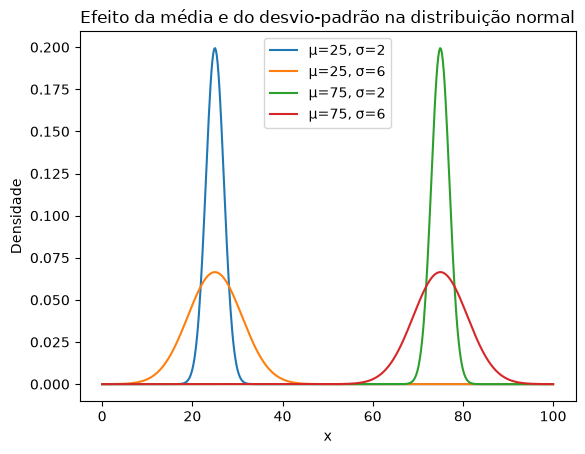

In [199]:
demonstra_parametros_curva_normal()

O Teorema Central do Limite (TCL) afirma que, para amostras suficientemente grandes, a distribuição das médias amostrais tende a se aproximar de uma distribuição normal, independentemente da distribuição da população original.

Dessa forma, mesmo que os dados de uma população não apresentem comportamento normal, as médias de várias amostras dessa população tendem a formar uma curva aproximadamente normal à medida que o tamanho das amostras aumenta.

In [200]:
def demonstrar_tcl(n, numero_amostras=10_000):
    amostras = np.random.randint(0, 101, size=(numero_amostras, n))

    medias = np.mean(amostras, axis=1)

    media = np.mean(amostras)
    desvio = np.std(amostras) / (n**(1/2))

    x = np.linspace(np.min(medias), np.max(medias), 500)
    y = curva_distribuicao_normal(x, media, desvio)

    plt.hist(medias, bins=30, density=True,
             alpha=0.7, color='green', label='Médias amostrais')

    plt.plot(x, y, color='black', label='Normal teórica')

    plt.title(f'Teorema Central do Limite: n = {n}')
    plt.xlabel('Média amostral')
    plt.ylabel('Densidade')
    plt.legend()
    plt.show()

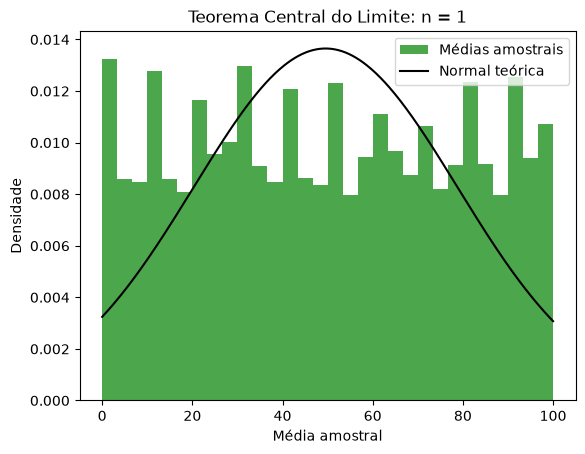

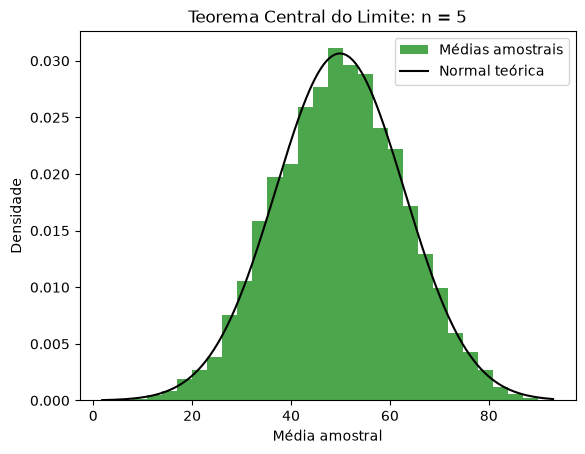

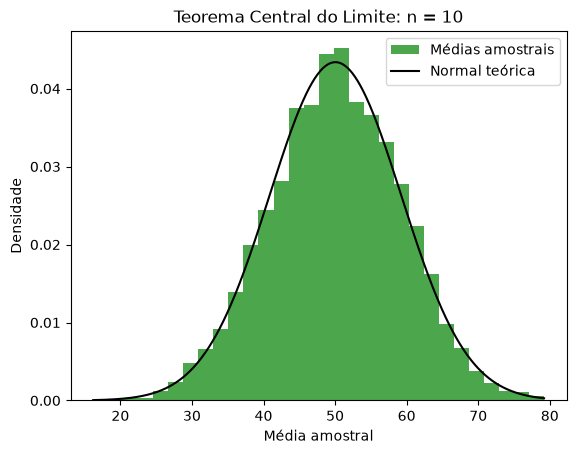

In [201]:
for n in [1, 5, 10]:
    demonstrar_tcl(n)

2. Distribuição Binomial

A distribuição binomial é uma distribuição de probabilidade discreta utilizada para representar o número de sucessos obtidos em um número fixo de tentativas independentes, nas quais existem apenas dois resultados possíveis: sucesso ou fracasso.

Ela é determinada pelo número de tentativas n e pela probabilidade de sucesso p. Diferentemente da distribuição normal, que é contínua, a distribuição binomial assume apenas valores inteiros, de 0 até n.

Sua forma pode variar de acordo com n e p, podendo apresentar maior ou menor simetria dependendo da probabilidade de sucesso.

$$P(X = k) = \binom{n}{k}p^{k}(1 - p)^{n-k}$$

$$\binom{n}{k}=\frac{n!}{k!(n-k)!}$$

In [202]:
import math

In [203]:
def distribuicao_binomial(n, p, k):
    numero_binomial = math.factorial(n)/(math.factorial(k)*math.factorial(n-k))
    return numero_binomial*p**k*(1-p)**(n-k)

Exemplo:

Uma moeda equilibrada é lançada 10 vezes. Qual é a probabilidade de obter exatamente 3 caras?

In [204]:
n = 10
k = 3
p = 0.50

In [208]:
P = distribuicao_binomial(n, p, k) * 100
f'{round(P, 1)}%'

'11.7%'

In [211]:
def plot_distribuicao_binomial(n, p):
    ks = np.arange(0, n + 1)

    probabilidades = [distribuicao_binomial(n, p, ki) for ki in ks]

    plt.bar(ks, probabilidades, color='green', alpha=0.7)

    plt.xlabel('Número de sucessos')
    plt.ylabel('Probabilidade')
    plt.title(f'Distribuição Binomial: n={n}, p={p}')

    plt.xticks(ks)
    plt.show()

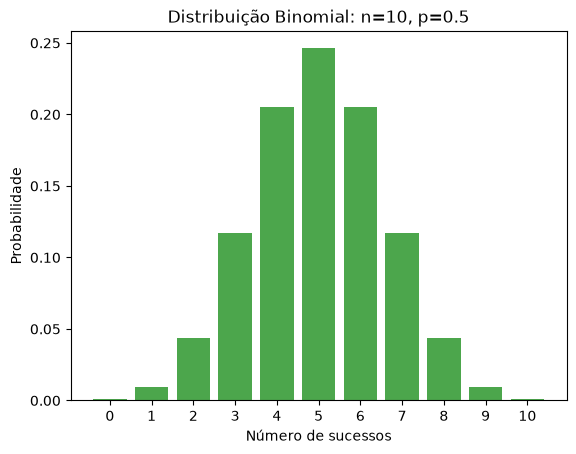

In [212]:
plot_distribuicao_binomial(n, p)